# Random Forest Classifier

#### Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#### Reading the data

In [2]:
df = pd.read_csv('data.csv')
df.head()

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


#### Extracting features (without columns that have high p value) and label

In [3]:
X = df.drop(columns=["Class", "Sample code number", "Uniformity of Cell Size", "Single Epithelial Cell Size"])
y = df["Class"]

#### Splitting the dataset into the Training set and Test set

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

#### Training the Random Forest Classification model on the Training set

In [23]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators = 25, criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",25
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

#### Predicting the Test set results

In [24]:
y_pred = classifier.predict(X_test)

#### Showing Confusion matrix, Accuracy and ROC AUC score

In [25]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, classification_report
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy}")
roc_auc = roc_auc_score(y_test, y_pred)
print(f"ROC AUC Score: {roc_auc}")

Confusion Matrix:
[[103   4]
 [  3  61]]
Accuracy Score: 0.9590643274853801
ROC AUC Score: 0.9578709112149533


In [26]:
cr = classification_report(y_test, y_pred)
print(f"Classification Report:\n{cr}")

Classification Report:
              precision    recall  f1-score   support

           2       0.97      0.96      0.97       107
           4       0.94      0.95      0.95        64

    accuracy                           0.96       171
   macro avg       0.96      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



In [21]:
accuracy_scores = []
error_rates = []
for i in range(1, 110):
    classifier_i = RandomForestClassifier(n_estimators = i, criterion = 'entropy', random_state = 0)
    classifier_i.fit(X_train, y_train)
    y_pred_i = classifier_i.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred_i))
    error_rate = np.mean(y_pred_i != y_test)
    error_rates.append(error_rate)

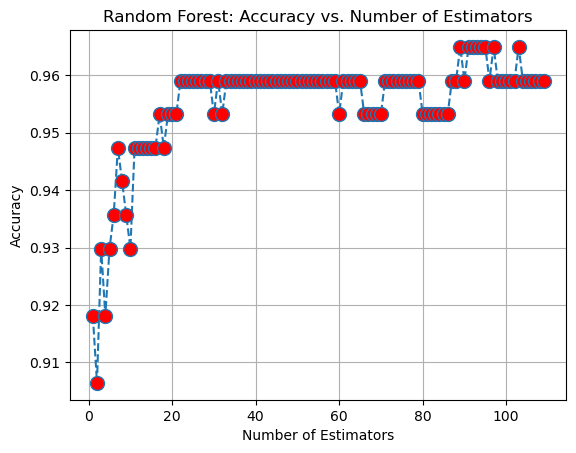

In [27]:
plt.plot(range(1, 110), accuracy_scores, linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('Random Forest: Accuracy vs. Number of Estimators')
plt.grid(True)
plt.show()

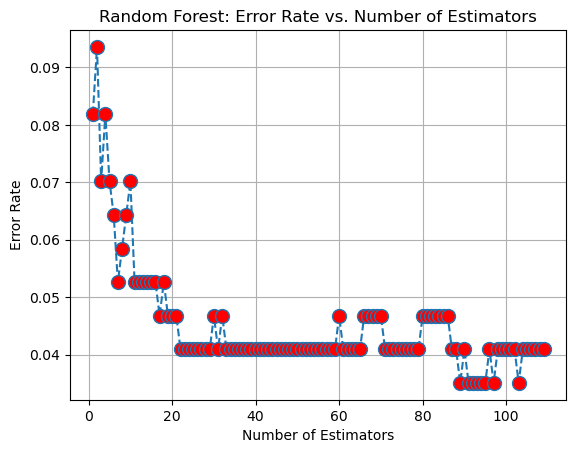

In [28]:
plt.plot(range(1, 110), error_rates, linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)
plt.xlabel('Number of Estimators')
plt.ylabel('Error Rate')
plt.title('Random Forest: Error Rate vs. Number of Estimators')
plt.grid(True)
plt.show()